# SCANIA Component X: Exploratory Data Analysis (EDA)

This notebook explores the **SCANIA Component X Dataset**, a real dataset released for the IDA 2024 Industrial Challenge. The data come from a fleet of SCANIA trucks (Sweden) and focus on predictive maintenance (PdM) of an anonymized engine component ("Component X").

## 1. Domain Characteristics and Temporal Structure
* **System Type**: Industrial commercial vehicles operating under real-world conditions, not simulated.
* **Operational Data (Multivariate Time Series)**: Readings extracted from vehicle control units at specific time intervals (identified by `vehicle_id` and `time_step`).
* **Signals Present**: The sensors do not report only traditional continuous values, but are structured as **numeric counters** (cumulative values) and **histograms** (value distributions across specific ranges).
* **Target Variable (TTE)**: The training labels are stored in `train_tte.csv`, which contains two key columns: `length_of_study_time_step` (the operational time steps) and `in_study_repair` (the binary fault/replacement label).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set_theme(style='whitegrid', palette='muted')

# 1. Load the labels and repair records (Time-To-Event)
# Make sure the file path matches your local directory
print("Loading the TTE file...")
train_tte = pd.read_csv('../data/train_tte.csv')

print(f"TTE file dimensions: {train_tte.shape}")
display(train_tte.head())


Loading the TTE file...
TTE file dimensions: (23550, 3)


,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


Class counts:
Healthy components (Label 0): 21278
Repaired components (Label 1): 2272


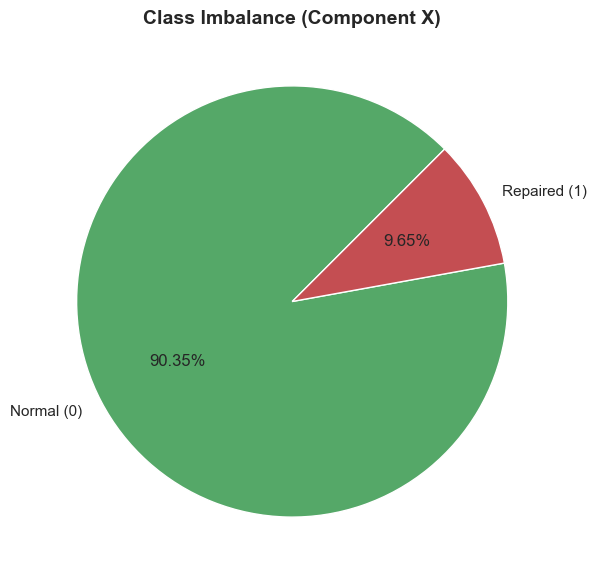

In [24]:
# Analysis of the imbalance in the target column 'in_study_repair'
class_counts = train_tte['in_study_repair'].value_counts()

print("Class counts:")
print(f"Healthy components (Label 0): {class_counts[0]}")
print(f"Repaired components (Label 1): {class_counts[1]}")

# Pie chart to show the imbalance
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    class_counts, 
    labels=['Normal (0)', 'Repaired (1)'], 
    colors=['#55A868', '#C44E52'], 
    autopct='%1.2f%%', 
    startangle=45,
    wedgeprops={'edgecolor': 'white'}
)
ax.set_title('Class Imbalance (Component X)', fontsize=14, fontweight='bold')
plt.show()


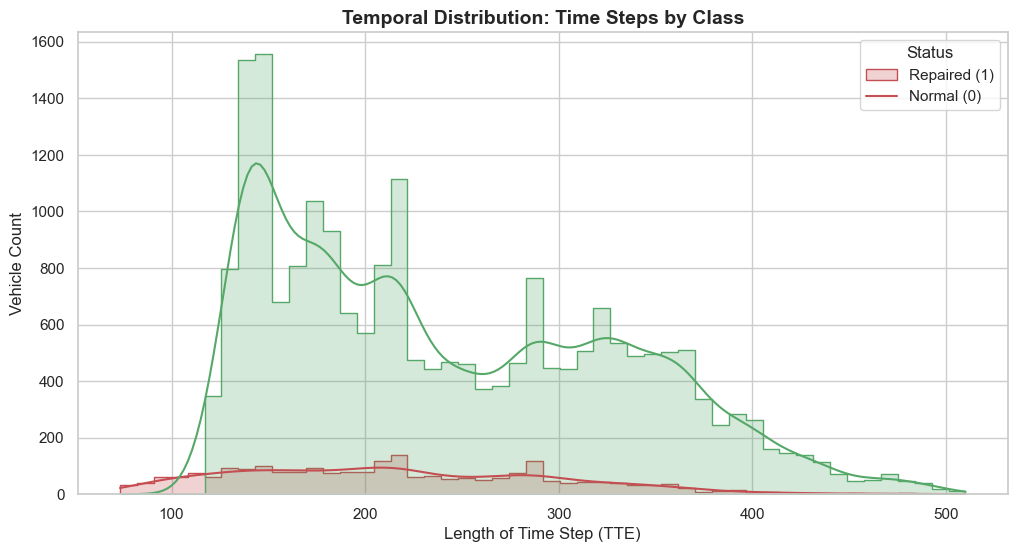

In [25]:
# Distribution of the study time length
plt.figure(figsize=(12, 6))
sns.histplot(
    data=train_tte, 
    x='length_of_study_time_step', 
    hue='in_study_repair', 
    bins=50, 
    kde=True, 
    palette=['#55A868', '#C44E52'],
    element='step'
)

plt.title('Temporal Distribution: Time Steps by Class', fontsize=14, fontweight='bold')
plt.xlabel('Length of Time Step (TTE)', fontsize=12)
plt.ylabel('Vehicle Count', fontsize=12)
plt.legend(title='Status', labels=['Repaired (1)', 'Normal (0)'])
plt.show()


## 2. Exploration of Technical Specifications

In this section we analyze the vehicle configurations in `train_specifications.csv`. We want to understand how the fleet is composed and, above all, whether certain technical configurations or use cases make "Component X" more vulnerable to failures.


In [ ]:
# Loading the vehicle specifications
print("Loading the Specifications file...")
train_specs = pd.read_csv('../data/train_specifications.csv')

print(f"Specifications file dimensions: {train_specs.shape}")
display(train_specs.head())

# Check missing values in the specifications
missing_specs = train_specs.isnull().mean() * 100
missing_specs = missing_specs[missing_specs > 0].sort_values(ascending=False)

if not missing_specs.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_specs.index[:15], y=missing_specs.values[:15], palette='flare')
    plt.title('Missing Values in Technical Specifications (%)', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('% Missing Data')
    plt.show()
else:
    print("No missing data detected in the technical specifications.")


Loading the Specifications file...
Specifications file dimensions: (23550, 9)


,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1


No missing data detected in the technical specifications.


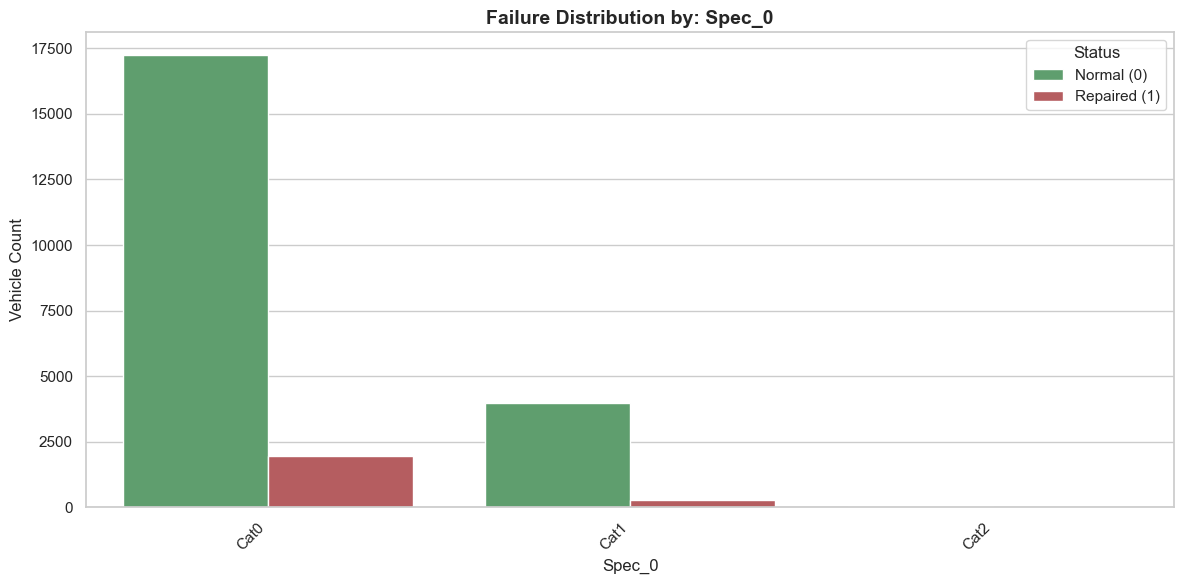

In [27]:
# We merge the specifications with the TTE labels
df_specs_labels = pd.merge(train_specs, train_tte, on='vehicle_id', how='inner')

# Choose an interesting categorical column (replace 'equipment_class' or 'truck_type' 
# with a real column visible in the dataframe if different)
# We use the first available categorical column name as an exploratory example
cat_col = df_specs_labels.select_dtypes(include=['object']).columns[0] 

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_specs_labels, 
    x=cat_col, 
    hue='in_study_repair', 
    palette=['#55A868', '#C44E52']
)

plt.title(f'Failure Distribution by: {cat_col}', fontsize=14, fontweight='bold')
plt.xlabel(cat_col)
plt.ylabel('Vehicle Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', labels=['Normal (0)', 'Repaired (1)'])
plt.tight_layout()
plt.show()


## 3. Exploration of Operational Data (Histogram Sensors)

The file `train_operational_readouts.csv` contains the actual "heartbeat" of the component. SCANIA, for reasons of efficiency and privacy, aggregates ECU data into two formats:
* **Counters**: Values that increase over time (e.g., total kilometers, total fuel consumption).
* **Histograms**: Arrays of bins that count how long the component operated under a specific condition (e.g., how long the temperature stayed between 80°C and 90°C).


In [ ]:
print("Loading the Operational Data file...")
train_op = pd.read_csv('../data/train_operational_readouts.csv')

print(f"Operational Data file dimensions: {train_op.shape}")
print(f"Number of unique vehicles monitored: {train_op['vehicle_id'].nunique()}")

# Show the first rows to inspect the format of the anonymized columns
display(train_op.head())

# Identify the columns that may belong to histograms
# In the SCANIA dataset they usually contain keywords such as 'bin' or sequential numeric suffixes
hist_columns = [col for col in train_op.columns if 'bin' in col.lower() or 'hist' in col.lower()]
print(f"\nFound {len(hist_columns)} columns that appear to belong to histograms.")


Loading the Operational Data file...
Operational Data file dimensions: (1122452, 107)
Number of unique vehicles monitored: 23550


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,0,11.2,167985.0,10787.0,7413813.0,2296.0,4110.0,1296420.0,1628265.0,630345.0,...,95728.0,15609.0,1984.0,8.0,784.0,150228.0,261904.0,93172.0,17874.0,452.0
1,0,11.4,167985.0,10787.0,7413813.0,2296.0,4111.0,1302855.0,1628265.0,630345.0,...,95729.0,15610.0,1984.0,8.0,784.0,150228.0,261905.0,93172.0,17874.0,452.0
2,0,19.6,331635.0,14525.0,13683604.0,2600.0,NaN,NaN,NaN,NaN,...,142900.0,19263.0,2441.0,12.0,1420.0,204832.0,313485.0,106464.0,19306.0,452.0
3,0,20.2,354975.0,15015.0,14540449.0,2616.0,NaN,NaN,NaN,NaN,...,150565.0,19832.0,2522.0,12.0,1444.0,211688.0,318901.0,107745.0,19406.0,453.0
4,0,21.0,365550.0,15295.0,14966985.0,2720.0,NaN,NaN,NaN,NaN,...,155913.0,20573.0,2562.0,12.0,1445.0,213956.0,323997.0,109514.0,19535.0,454.0



Found 0 columns that appear to belong to histograms.


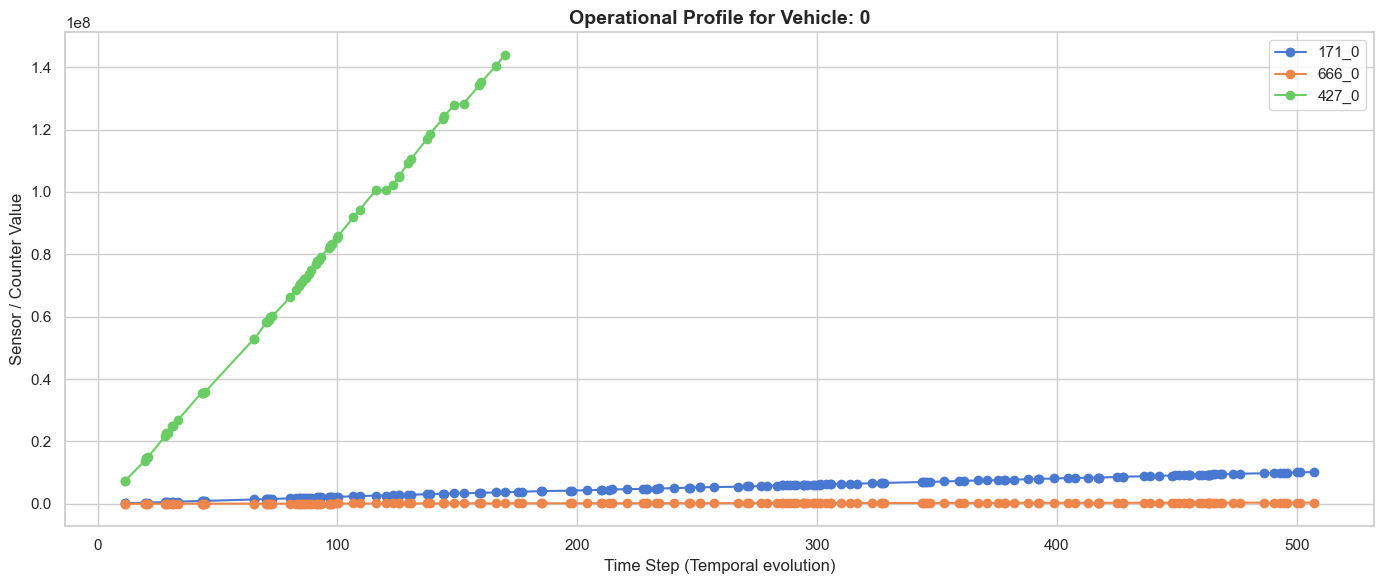

In [29]:
# Select a random vehicle_id to visualize its profile
sample_vehicle = train_op['vehicle_id'].unique()[0]
df_sample = train_op[train_op['vehicle_id'] == sample_vehicle].sort_values('time_step')

# Select 3 operational variables at random (assuming anonymized columns such as var_1, var_2...)
# We adapt by selecting the third, fourth, and fifth numeric columns (excluding id and time_step)
cols_to_plot = df_sample.select_dtypes(include=[np.number]).columns[2:5]

plt.figure(figsize=(14, 6))
for col in cols_to_plot:
    plt.plot(df_sample['time_step'], df_sample[col], marker='o', label=col)

plt.title(f'Operational Profile for Vehicle: {sample_vehicle}', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (Temporal evolution)', fontsize=12)
plt.ylabel('Sensor / Counter Value', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


## 4. Data Integration (Merge) and Statistical Comparison

To quantify the physical impact of degradation on "Component X", we need to cross operational sensor data with the vehicle health state. We will perform a *merge* between `train_operational_readouts` and `train_tte`.
Next, we will use boxplots to compare the distributions of several key features between "Healthy" vehicles (those that did not undergo repairs during the study) and "Repaired" vehicles (those that experienced a failure).


In [30]:
print("Merging Operational Data with TTE labels...")

# Merge the sensor data with the target variable
df_merged = pd.merge(train_op, train_tte, on='vehicle_id', how='inner')

print(f"Merged dataset dimensions: {df_merged.shape}")

# Verify that the merge worked by showing a portion of the data
display(df_merged[['vehicle_id', 'time_step', 'length_of_study_time_step', 'in_study_repair']].head())


Merging Operational Data with TTE labels...
Merged dataset dimensions: (1122452, 109)


,vehicle_id,time_step,length_of_study_time_step,in_study_repair
0,0,11.2,510.0,0
1,0,11.4,510.0,0
2,0,19.6,510.0,0
3,0,20.2,510.0,0
4,0,21.0,510.0,0


C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\3335489805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\3335489805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\3335489805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Utente\AppData\Local\Temp\ipykernel_17676\3335489805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

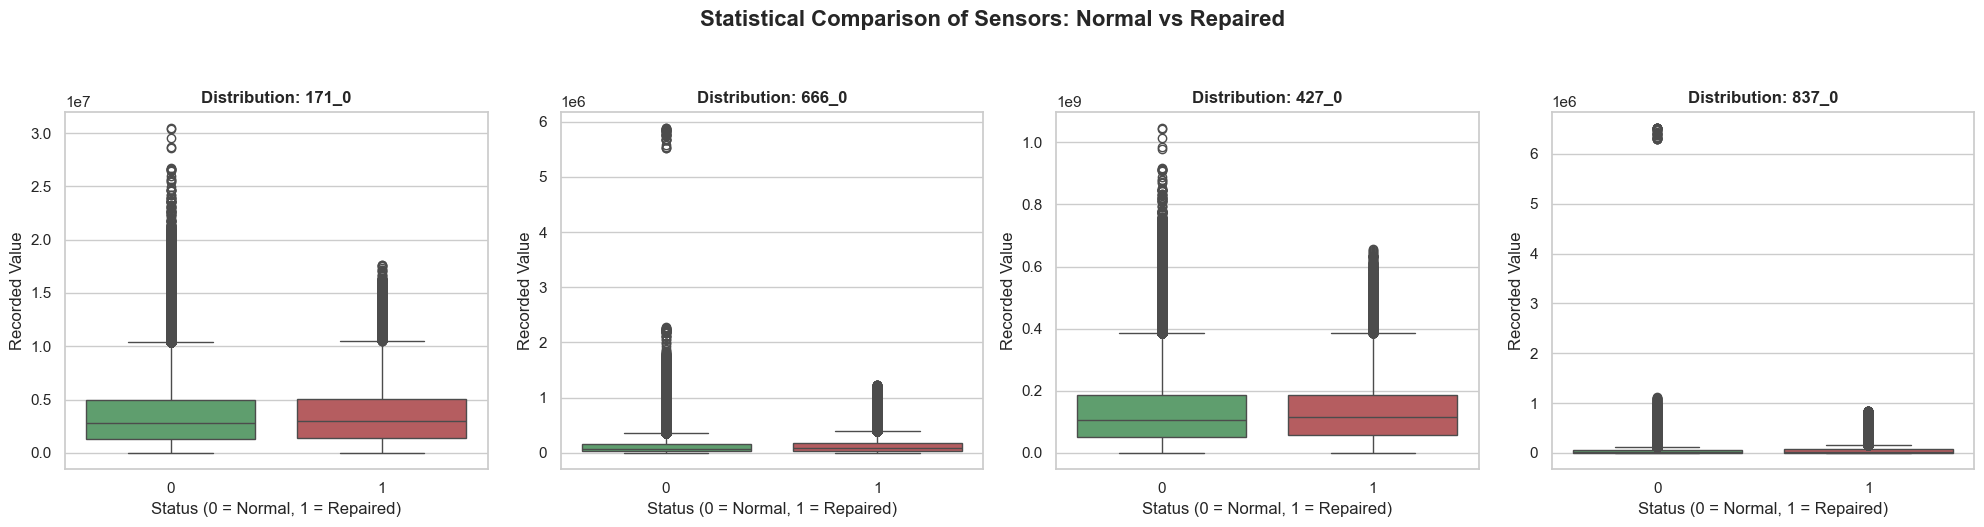

In [31]:
# Select the first 4 numerical operational features (excluding vehicle_id, time_step, and the targets)
# You can change the index [2:6] to explore other blocks of features (e.g., histogram bins)
features_to_compare = train_op.select_dtypes(include=[np.number]).columns[2:6]

# Create a grid of subplots for the boxplots
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, feature in enumerate(features_to_compare):
    sns.boxplot(
        x='in_study_repair', 
        y=feature, 
        data=df_merged, 
        ax=axes[i], 
        palette=['#55A868', '#C44E52']
    )
    
    # Formatting of individual plots
    axes[i].set_title(f'Distribution: {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Status (0 = Normal, 1 = Repaired)')
    axes[i].set_ylabel('Recorded Value')

plt.suptitle('Statistical Comparison of Sensors: Normal vs Repaired', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## 5. Correlation Heatmap

In the SCANIA operational data there are many variables. We calculate Pearson correlation to identify possible redundancies between sensors (multicollinearity) or to discover which operational features are more linearly correlated with the failure label (`in_study_repair`). For readability, we select a subset of the most representative variables.


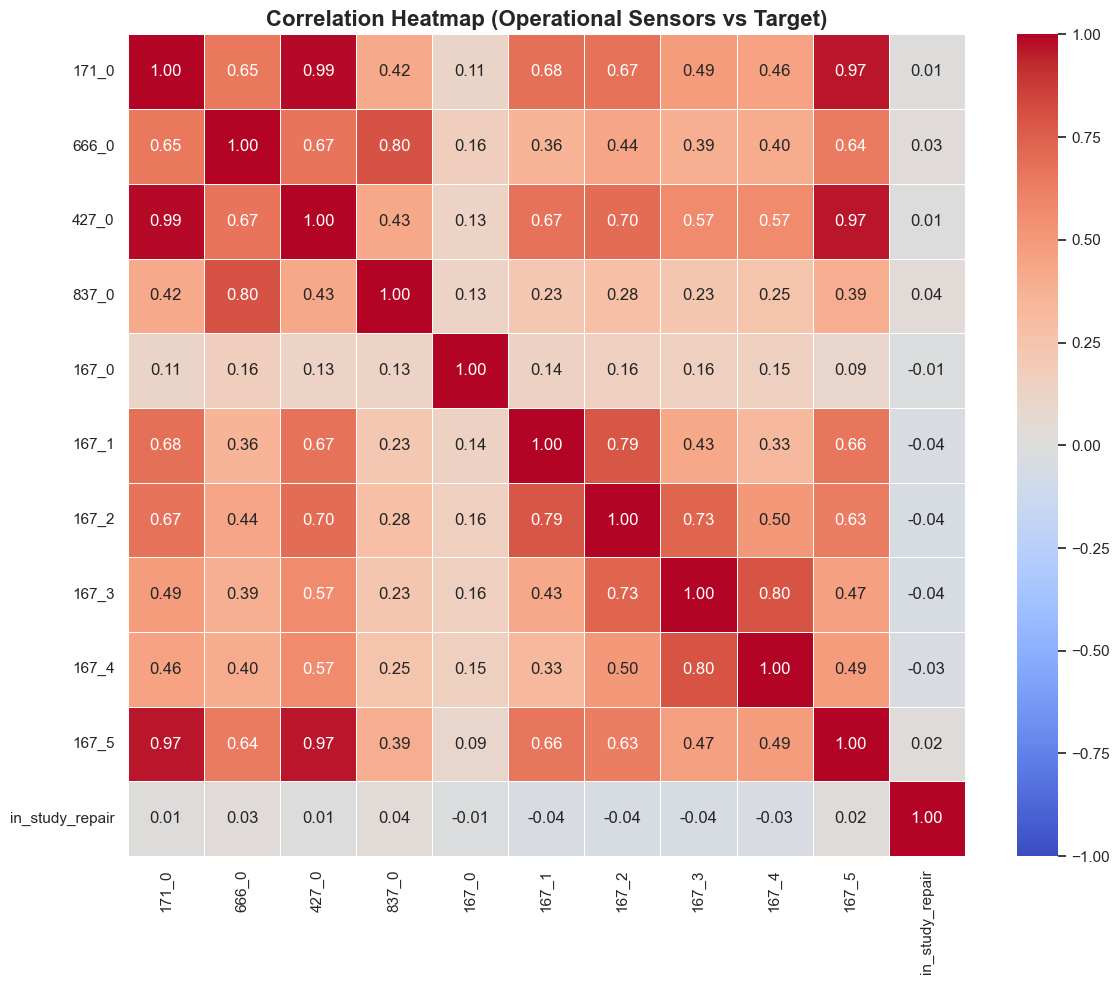

In [32]:
# Select a subset of variables: the first 10 numerical features and the target variable
# (If the dataset has hundreds of columns, a full heatmap would be unreadable)
num_features = train_op.select_dtypes(include=[np.number]).columns[2:12].tolist()
cols_to_correlate = num_features + ['in_study_repair']

plt.figure(figsize=(12, 10))
corr_matrix = df_merged[cols_to_correlate].corr()

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)

plt.title("Correlation Heatmap (Operational Sensors vs Target)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Domain Exploration (Specifications vs Sensors)

Inspired by transfer learning techniques, we want to verify whether the physical distribution of operational data shifts depending on the vehicle specifications. We combine operational data with factory configurations to see whether, for example, one truck category stresses "Component X" more than another.


Integrating Technical Specifications for Domain Analysis...


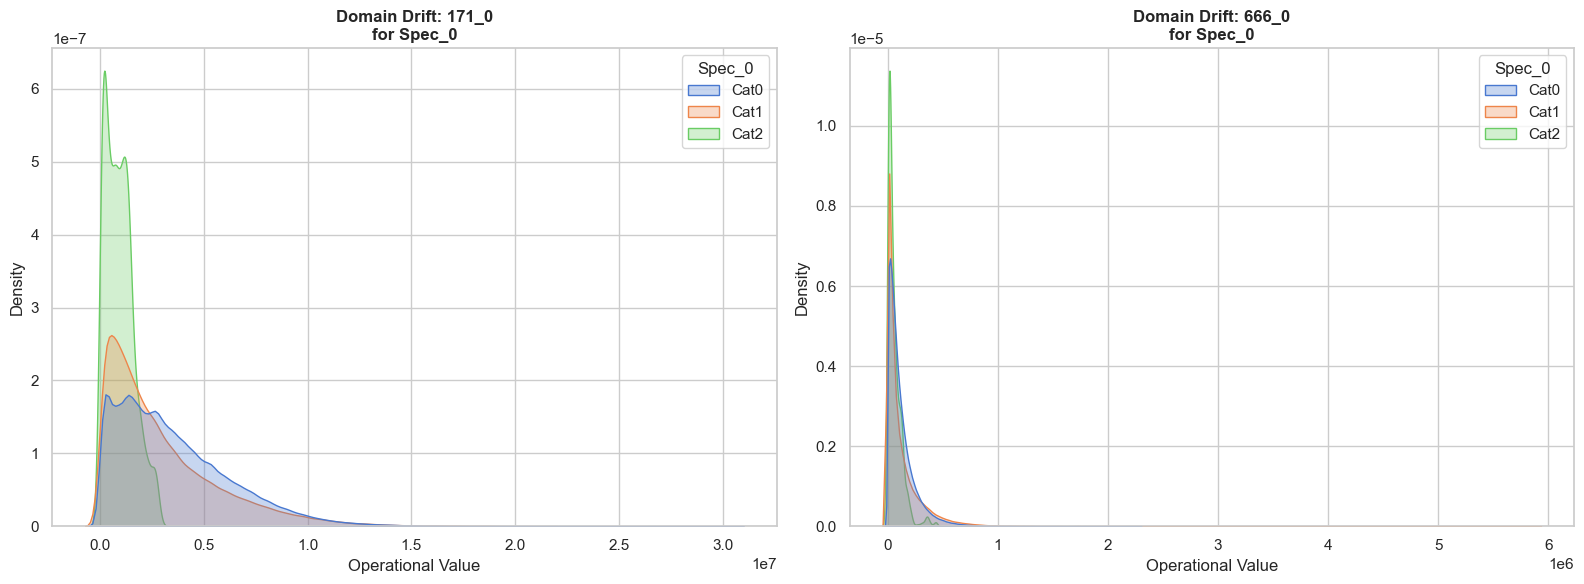

In [33]:
print("Integrating Technical Specifications for Domain Analysis...")

# Merge the merged dataset (Operational + TTE) with the technical specifications
df_full = pd.merge(df_merged, train_specs, on='vehicle_id', how='left')

# Select a categorical column from the specifications (e.g., the vehicle class)
cat_col_domain = train_specs.select_dtypes(include=['object']).columns[0]

# Select a couple of operational features to analyze
features_for_domain = num_features[:2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, feature in enumerate(features_for_domain):
    # Generate a Kernel Density Estimate (KDE) plot
    sns.kdeplot(
        data=df_full, 
        x=feature, 
        hue=cat_col_domain, 
        ax=axes[i], 
        common_norm=False, 
        fill=True, 
        alpha=0.3
    )
    axes[i].set_title(f'Domain Drift: {feature}\nfor {cat_col_domain}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Operational Value')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


## 7. Feature Engineering and Failure Trajectory (Degradation Path)

The SCANIA operational data contain multidimensional histograms. To extract a readable physical signal, we will aggregate the bins of a histogram sensor by summing them. In this way, we will compute the **total exposure** of the vehicle to a specific operating condition.

Next, we will isolate a vehicle that underwent a repair and plot the value of this aggregated sensor against the **Time-To-Event (TTE)**. We will invert the X-axis to simulate a countdown: as we approach zero (the failure moment), we will observe how the accumulated stress on the component changes.


In [34]:
print("Engineering histogram-based features...")

# Assume we want to aggregate the sensor 'hist_1' (you can replace it with a real histogram name from the dataframe)
# Find all columns that represent the bins of this specific histogram
hist_target_name = '167' # We use the feature cluster 167_x seen in the heatmap as an example
hist_bins = [col for col in df_merged.columns if hist_target_name in col and col != 'in_study_repair']

# Create a new feature: the sum of all bins (e.g., total exposure time to that stress)
df_merged[f'total_exposure_{hist_target_name}'] = df_merged[hist_bins].sum(axis=1)

print(f"Created new aggregated feature: 'total_exposure_{hist_target_name}' from {len(hist_bins)} bins.")
display(df_merged[['vehicle_id', 'time_step', f'total_exposure_{hist_target_name}']].head())


Engineering histogram-based features...
Created new aggregated feature: 'total_exposure_167' from 10 bins.


,vehicle_id,time_step,total_exposure_167
0,0,11.2,12536776.0
1,0,11.4,12543213.0
2,0,19.6,0.0
3,0,20.2,0.0
4,0,21.0,0.0


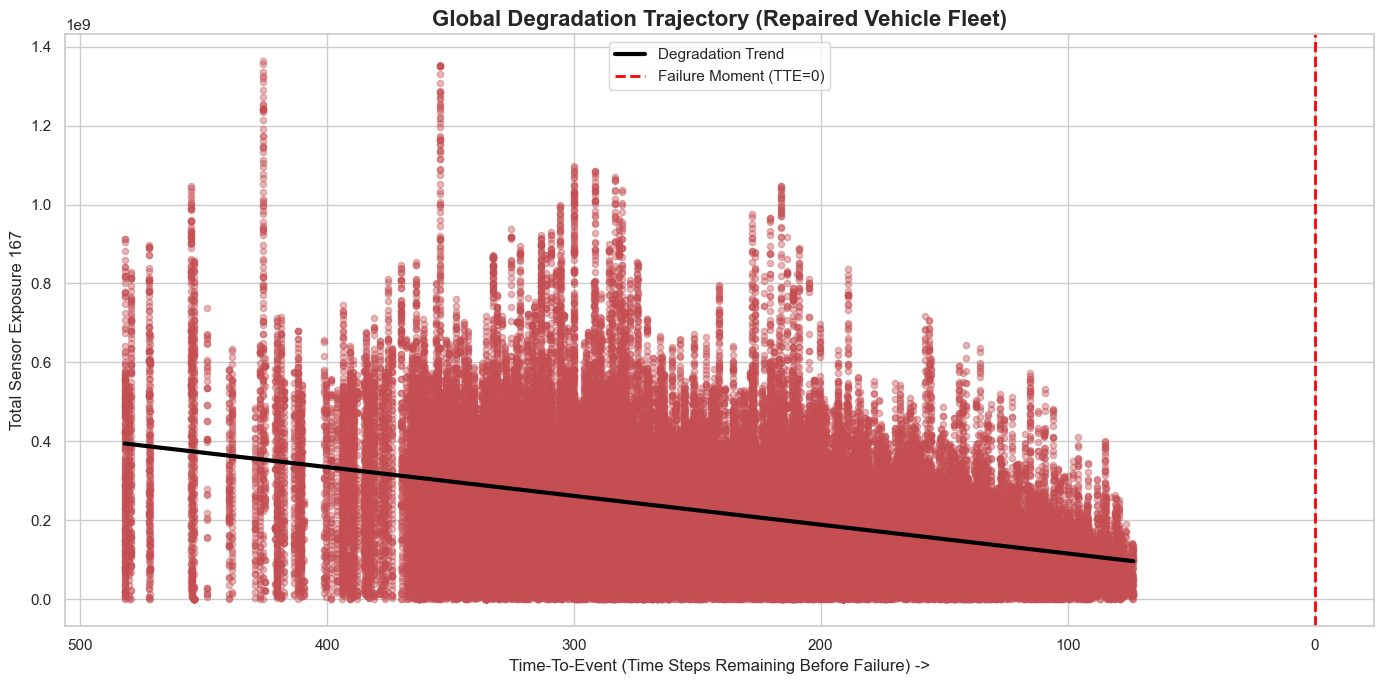

In [35]:
# 1. Select all vehicles that experienced a repair
df_failed_fleet = df_merged[df_merged['in_study_repair'] == 1].copy()

# 2. Create the scatter plot with a regression line
plt.figure(figsize=(14, 7))

# Use seaborn regplot to plot the points and automatically compute a regression line
sns.regplot(
    data=df_failed_fleet,
    x='length_of_study_time_step', 
    y=f'total_exposure_{hist_target_name}',
    scatter_kws={'alpha': 0.4, 'color': '#C44E52', 's': 20}, # Semi-transparent points to show density
    line_kws={'color': 'black', 'linewidth': 3, 'label': 'Degradation Trend'}
)

# 3. The countdown effect: invert the X-axis!
plt.gca().invert_xaxis() 
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Failure Moment (TTE=0)')

plt.title('Global Degradation Trajectory (Repaired Vehicle Fleet)', fontsize=16, fontweight='bold')
plt.xlabel('Time-To-Event (Time Steps Remaining Before Failure) ->', fontsize=12)
plt.ylabel(f'Total Sensor Exposure {hist_target_name}', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()
